In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,mean_squared_error,roc_auc_score,roc_curve
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import matthews_corrcoef
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import XGBClassifier

In [2]:
%matplotlib inline

In [3]:
data = pd.read_csv('../data/creditcard.csv')

In [4]:
data.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
data.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
data.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
data.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

# Train test and split

In [10]:
# Min-max normalization
numeric_features = data.dtypes[data.dtypes != 'object'].index
data[numeric_features] = data[numeric_features].apply(
    lambda x: (x - x.min()) / (x.max()-x.min()))
# Fill empty values by 0
data = data.fillna(0)

In [11]:
labelencoder = LabelEncoder()
data.iloc[:, -1] = labelencoder.fit_transform(data.iloc[:, -1])
#X = data.drop([' Label'], axis=1).values
#Y = data.iloc[:, -1].values.reshape(-1,1)
#Y = np.ravel(Y)
X = data.drop('Class', axis=1)
Y = data['Class']
Y = labelencoder.fit_transform(Y)  # Ensure consistent encoding
print("Encoded classes:", labelencoder.classes_)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y)

Encoded classes: [0. 1.]


In [12]:
X_train.shape

(227845, 30)

In [13]:
Y_test.shape

(56962,)

In [14]:
pd.Series(Y_train).value_counts()

0    227451
1       394
Name: count, dtype: int64

Calculating the correlation matrix...
Correlation Matrix (preview):
          Time            V1            V2            V3            V4  \
Time  1.000000  1.173963e-01 -1.059333e-02 -4.196182e-01 -1.052602e-01   
V1    0.117396  1.000000e+00  1.746106e-14  1.027566e-13  1.486596e-14   
V2   -0.010593  1.746106e-14  1.000000e+00 -7.599107e-14 -1.710874e-14   
V3   -0.419618  1.027566e-13 -7.599107e-14  1.000000e+00  1.237002e-14   
V4   -0.105260  1.486596e-14 -1.710874e-14  1.237002e-14  1.000000e+00   

                V5            V6            V7            V8            V9  \
Time  1.730721e-01 -6.301647e-02  8.471437e-02 -3.694943e-02 -8.660434e-03   
V1    5.920763e-14  1.705832e-14 -3.063624e-14  5.470123e-15 -2.111352e-14   
V2    3.867793e-14 -5.417328e-15  1.133256e-14 -1.572443e-14 -5.282469e-15   
V3   -3.179412e-13 -9.050933e-15  5.412571e-14  3.602720e-15  2.920132e-14   
V4   -9.365645e-14  2.673617e-15  5.851469e-15 -5.392357e-16  3.331727e-15   

      ...         

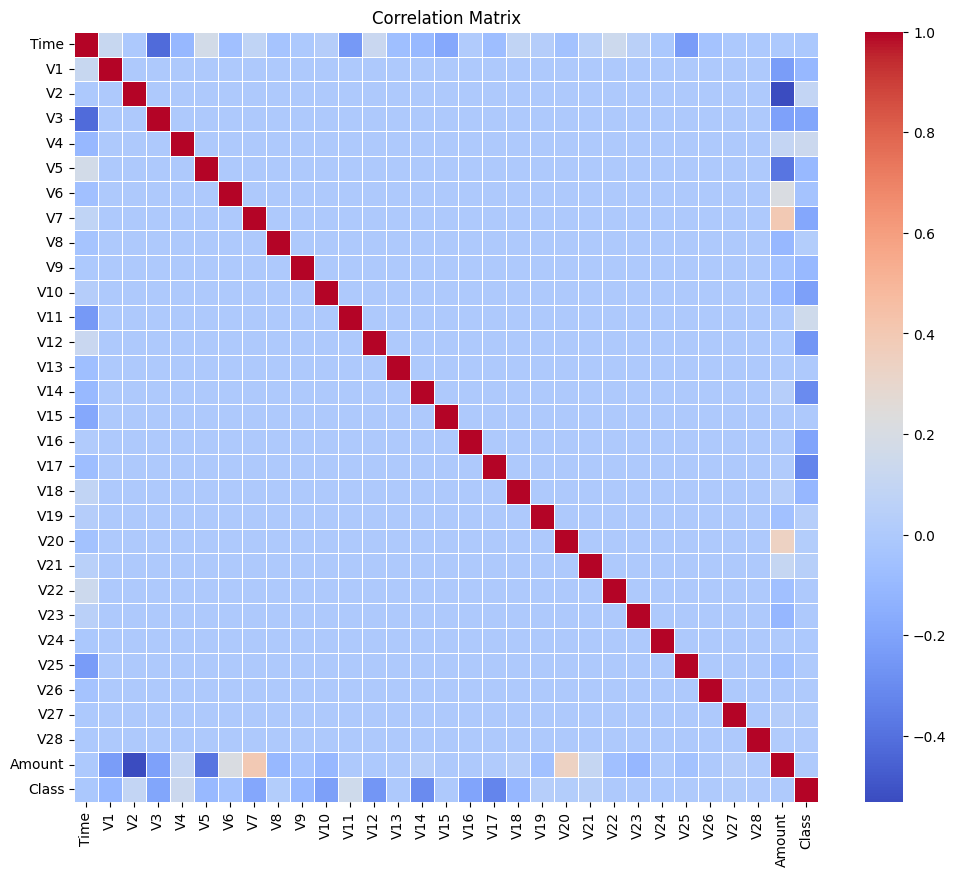

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Correlation with the target variable:
Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


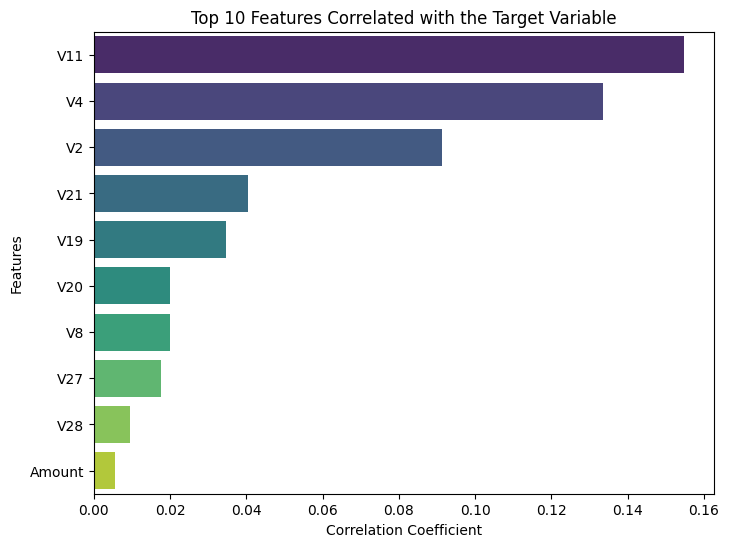

In [16]:
# Analyze correlation with the target variable ("Class")
if 'Class' in correlation_matrix.columns:
    target_corr = correlation_matrix['Class'].sort_values(ascending=False)
    print("Correlation with the target variable:")
    print(target_corr)

    # Visualize the strongest correlations with the target variable
    top_features = target_corr[1:11]  # Exclude correlation with itself
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_features.values, y=top_features.index, hue=top_features.index, dodge=False, palette='viridis', legend=False)
    plt.title('Top 10 Features Correlated with the Target Variable')
    plt.xlabel('Correlation Coefficient')
    plt.ylabel('Features')
    plt.show()
else:
    print("The 'Class' column does not exist in the dataset.")

In [17]:
# Check the range of correlation values
max_corr = correlation_matrix.where(~correlation_matrix.isna()).max().max()
min_corr = correlation_matrix.where(~correlation_matrix.isna()).min().min()

# Check for NaN values in the correlation matrix
#print("Number of NaN values in the correlation matrix:", correlation_matrix.isna().sum().sum())

# Lower the threshold for moderate correlations
threshold = 0.9  # Adjust to a lower value
strong_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

Strongly correlated features (>|0.9|):


In [18]:
import numpy as np
import pandas as pd

# Combine train and test sets temporarily
X_full = pd.concat([X_train, X_test], axis=0)

# Keep only numeric columns for correlation calculation
X_numeric = X_full.select_dtypes(include=np.number)

# Compute correlation matrix
corr_matrix = X_numeric.corr()

# Check the range of correlation values
max_corr = corr_matrix.where(~corr_matrix.isna()).max().max()
min_corr = corr_matrix.where(~corr_matrix.isna()).min().min()
print(f"Correlation range: min={min_corr:.2f}, max={max_corr:.2f}")

# Lower the threshold for moderate correlations
threshold = 0.9
strong_corr_pairs = []

# Find pairs of strongly correlated features
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            strong_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print(f"Strongly correlated features (>|{threshold}|):")
for pair in strong_corr_pairs:
    print(f"{pair[0]} and {pair[1]} : {pair[2]:.2f}")

# Extract upper triangle
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns to drop with correlation > threshold
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
print(f"⚠️ Highly correlated features to drop (>|{threshold}|): {len(to_drop)}")
print(to_drop)

# Drop those columns from original train and test sets
X_train_reduced = X_train.drop(columns=to_drop)
X_test_reduced = X_test.drop(columns=to_drop)

print(f"✅ Reduced training features: {X_train_reduced.shape[1]} (from {X_train.shape[1]})")
print(f"✅ Reduced test features: {X_test_reduced.shape[1]} (same columns kept)")

X = pd.concat([pd.DataFrame(X_train_reduced), pd.DataFrame(X_test_reduced)], axis=0).reset_index(drop=True)

Correlation range: min=-0.53, max=1.00
Strongly correlated features (>|0.9|):
⚠️ Highly correlated features to drop (>|0.9|): 0
[]
✅ Reduced training features: 30 (from 30)
✅ Reduced test features: 30 (same columns kept)


In [19]:
print(type(Y))
print(Y.dtype)
print(np.unique(Y))
pd.Series(Y_train).value_counts()

<class 'numpy.ndarray'>
int64
[0 1]


0    227451
1       394
Name: count, dtype: int64

# Outliers removal

In [20]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import shapiro
from sklearn.ensemble import IsolationForest


def check_outliers(X, Y, threshold=3, iqr_factor=1.5):
    """
    Check if outliers exist in the dataset (X and Y) using Z-score or IQR.
    Returns True if outliers are detected in either X or Y, False otherwise.
    """
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    
    # Ensure Y is a pandas Series
    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)
    
    # Filter only numeric columns for X
    X_numeric = X_normal.select_dtypes(include=['number'])
    
    # Calculate Z-scores for X and Y
    z_scores_X = np.abs(stats.zscore(X_numeric))
    z_scores_Y = np.abs(stats.zscore(Y_normal))
    
    outliers_zscore_X = (z_scores_X > threshold).any().any()
    outliers_zscore_Y = (z_scores_Y > threshold).any()
    
    # Calculate IQR for X and Y
    Q1_X = X_numeric.quantile(0.25)
    Q3_X = X_numeric.quantile(0.75)
    IQR_X = Q3_X - Q1_X
    
    Q1_Y = Y.quantile(0.25)
    Q3_Y = Y.quantile(0.75)
    IQR_Y = Q3_Y - Q1_Y
    
    outliers_iqr_X = ((X_numeric < (Q1_X - iqr_factor * IQR_X)) | (X_numeric > (Q3_X + iqr_factor * IQR_X))).any().any()
    outliers_iqr_Y = ((Y_normal < (Q1_Y - iqr_factor * IQR_Y)) | (Y_normal > (Q3_Y + iqr_factor * IQR_Y))).any()
    
    return outliers_zscore_X or outliers_zscore_Y or outliers_iqr_X or outliers_iqr_Y
    
def remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=1.5):
    """
    Removes outliers from normal transactions only.
    """

    if not isinstance(Y, pd.Series):
        Y = pd.Series(Y, index=X.index)

    # Separate normal and fraudulent transactions
    X_normal = X[Y == 0].select_dtypes(include=['number'])  # Select numeric columns
    Y_normal = Y[Y == 0]
    X_fraud = X[Y == 1]
    Y_fraud = Y[Y == 1]

    # Outlier removal
    if method == "auto":
        print("Automatically selecting outlier removal method...")
        if X_normal.std().mean() < threshold:
            print("Using Z-score for outlier removal...")
            X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)
        else:
            print("Using IQR for outlier removal...")
            X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
            Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "zscore":
        print("Using Z-score for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_zscore(X_normal, Y_normal, threshold)

    elif method == "iqr":
        print("Using IQR for outlier removal...")
        X_normal_cleaned = remove_outliers_using_iqr(X_normal, iqr_factor)
        Y_normal_cleaned = Y_normal.loc[X_normal_cleaned.index]

    elif method == "isolation_forest":
        print("Using Isolation Forest for outlier removal...")
        X_normal_cleaned, Y_normal_cleaned = remove_outliers_using_if(X_normal, Y_normal)

    # Reunify data
    X_cleaned = pd.concat([X_normal_cleaned, X_fraud], axis=0).sort_index()
    Y_cleaned = pd.concat([Y_normal_cleaned, Y_fraud], axis=0).sort_index()

    return X_cleaned, Y_cleaned

def remove_outliers_using_zscore(X, Y, threshold):
    """
    Removes outliers using the Z-score method.
    """
    z_scores = np.abs(stats.zscore(X))
    X_filtered = X[(z_scores < threshold).all(axis=1)]
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

def remove_outliers_using_iqr(X, iqr_factor=1.5):
    """
    Removes outliers using the IQR method.
    """
    Q1 = X.quantile(0.25)
    Q3 = X.quantile(0.75)
    IQR = Q3 - Q1
    return X[~((X < (Q1 - iqr_factor * IQR)) | (X > (Q3 + iqr_factor * IQR))).any(axis=1)].copy()

def remove_outliers_using_if(X, Y, contamination=0.05):
    """
    Removes outliers using Isolation Forest.
    """
    model = IsolationForest(contamination=contamination, random_state=42)
    preds = model.fit_predict(X)
    X_filtered = X[preds != -1]  # IsolationForest marks outliers as -1
    Y_filtered = Y.loc[X_filtered.index]
    return X_filtered, Y_filtered

# Example usage:
# X_cleaned, Y_cleaned = remove_outliers(X, Y, method="auto")

In [21]:
# Assuming X is your DataFrame (features) and Y is your Series (target)
outliers_exist = check_outliers(X, Y)
print(f"Outliers detected: {outliers_exist}")

# Step 2: Remove outliers if they exist
if outliers_exist:
    X_filtered, y_filtered = remove_outliers(X, Y, method="auto", threshold=3, iqr_factor=2.0)
    print("Outliers removed.")
else:
    print("No outliers detected. Data is clean.")

print("Cleaned Features (X):")
print(X_filtered)
print("\nCleaned Target (Y):")
print(y_filtered)

Outliers detected: True
Automatically selecting outlier removal method...
Using Z-score for outlier removal...
Outliers removed.
Cleaned Features (X):
            Time        V1        V2        V3        V4        V5        V6  \
1       0.720386  0.992868  0.766743  0.784411  0.262921  0.785532  0.296185   
3       0.767536  0.997125  0.751429  0.824459  0.177984  0.756331  0.259497   
4       0.343529  0.950670  0.756586  0.839422  0.098779  0.770535  0.261537   
5       0.459535  0.980727  0.750788  0.834739  0.171864  0.760120  0.271845   
6       0.647623  0.990609  0.768933  0.833773  0.405276  0.768046  0.277757   
...          ...       ...       ...       ...       ...       ...       ...   
284802  0.268120  0.943632  0.769637  0.880022  0.279108  0.766168  0.280274   
284803  0.730994  0.982041  0.752210  0.831017  0.291464  0.757879  0.261344   
284804  0.961098  0.940494  0.774488  0.840801  0.093081  0.766275  0.258555   
284805  0.947897  0.994989  0.755818  0.822532  0

In [22]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.2, random_state=42)

# Oversampling using SMOTE

In [23]:
from collections import Counter
smote = SMOTE(sampling_strategy=0.8, random_state=42)
#print("Unique classes in Y:", np.unique(Y))
#print("Class distribution:\n", pd.Series(Y).value_counts())
# Apply SMOTE to balance the classes
X_resampled, Y_resampled = smote.fit_resample(X_train, y_train)

# Create a new DataFrame with the resampled data
data_resampled = pd.concat([pd.DataFrame(X_resampled), pd.Series(Y_resampled, name='Class')], axis=1)

# Display the class distribution after SMOTE
class_distribution_after = Counter(data_resampled['Class'])
print("Class Distribution After SMOTE:", class_distribution_after)

Class Distribution After SMOTE: Counter({0: 197266, 1: 157812})


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, Y_resampled, train_size = 0.8, test_size = 0.2, random_state = 42,stratify = Y_resampled)

Calculating the correlation matrix...
Correlation Matrix (preview):
          Time        V1        V2        V3        V4        V5        V6  \
Time  1.000000  0.163228 -0.017818 -0.547318 -0.162383  0.200129 -0.060528   
V1    0.163228  1.000000 -0.319085 -0.339774  0.136382 -0.037722 -0.032478   
V2   -0.017818 -0.319085  1.000000  0.049455  0.111299  0.229186 -0.083184   
V3   -0.547318 -0.339774  0.049455  1.000000  0.091926 -0.251424 -0.010655   
V4   -0.162383  0.136382  0.111299  0.091926  1.000000  0.018087 -0.044147   

            V7        V8        V9  ...       V21       V22       V23  \
Time  0.122980 -0.101788  0.021382  ...  0.049681  0.173910  0.044251   
V1   -0.179699 -0.185164  0.048391  ... -0.059438 -0.027467  0.012273   
V2    0.286796  0.007157  0.066182  ... -0.095485 -0.036866 -0.120198   
V3   -0.124472  0.055797 -0.024927  ... -0.019067 -0.055915 -0.032077   
V4    0.052948 -0.033235  0.066577  ...  0.085931 -0.005554  0.075207   

           V24       V25

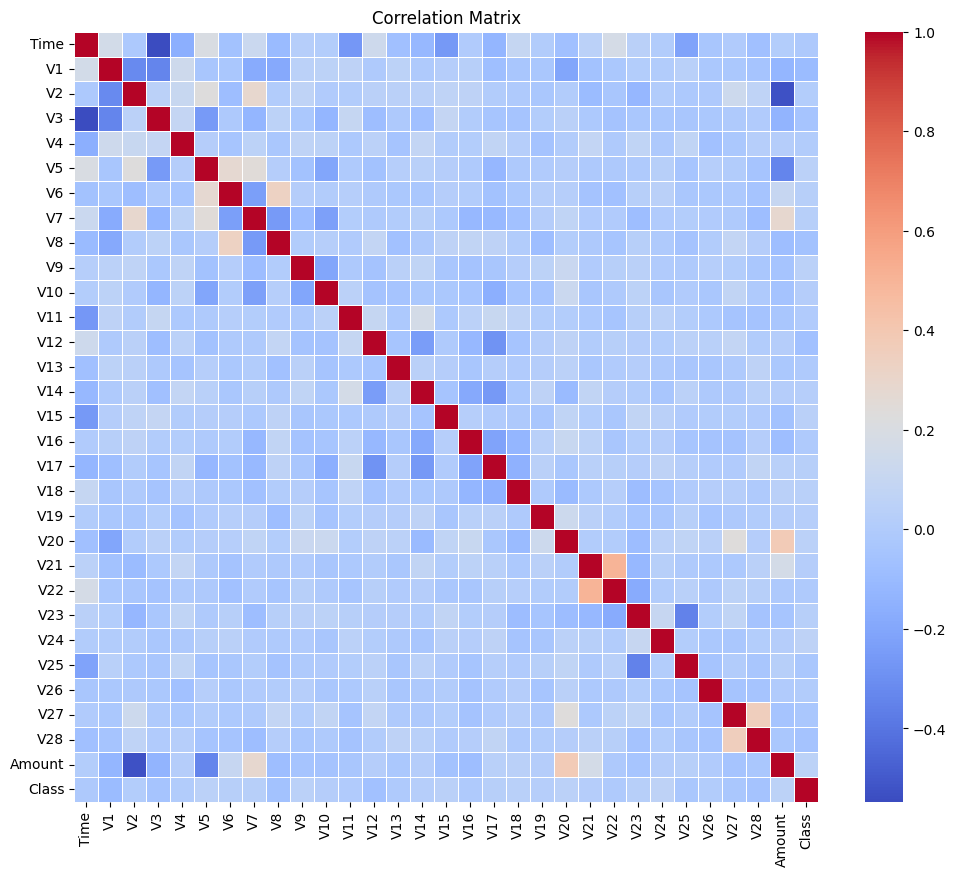

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
print("Calculating the correlation matrix...")
correlation_matrix = data_resampled.corr()

# Display the first few rows of the correlation matrix
print("Correlation Matrix (preview):")
print(correlation_matrix.head())

# Visualize the correlation matrix with a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# Feature importance

In [26]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "XGBoost": XGBClassifier(n_estimators=50),
    #"CataBoost": CatBoostClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50)
}

In [27]:
feature_importances = np.zeros(X_resampled.shape[1])
for name, model in models.items():
    # Train the model
    model.fit(X_resampled,Y_resampled)
    if hasattr(model, "feature_importances_"):
        #feature_importances = model.feature_importances_
        feature_importances += model.feature_importances_
        print(f"{name} Feature Importances:\n{model.feature_importances_}")
    else:
        print(f"{name} does not have feature_importances_ attribute.")

Decision Tree Feature Importances:
[0.04657439 0.0413618  0.02372309 0.05001722 0.03065606 0.0237061
 0.0168786  0.0276474  0.03089755 0.03215779 0.03075747 0.04128569
 0.03226377 0.05049113 0.03421157 0.03331104 0.02981873 0.02875872
 0.04159466 0.04154521 0.02063114 0.02056274 0.02990381 0.02287468
 0.04647397 0.03442227 0.0417654  0.01765121 0.03292108 0.04513571]
Random Forest Feature Importances:
[0.05086481 0.04581827 0.02586473 0.03897282 0.02959281 0.0275401
 0.0265877  0.02896283 0.03104014 0.03755915 0.02757444 0.03359621
 0.03614156 0.04102172 0.0333715  0.03400801 0.02903556 0.03131222
 0.0361179  0.03247132 0.02521232 0.02315787 0.03022494 0.02478625
 0.03828503 0.03072625 0.03921435 0.02843344 0.03408209 0.04842364]
Extra Trees Feature Importances:
[0.05405904 0.04032813 0.02665487 0.0364835  0.03230125 0.02994012
 0.03184764 0.02899296 0.02735789 0.03396843 0.0282851  0.03874269
 0.03846924 0.04220544 0.03362324 0.03628473 0.03121437 0.03317579
 0.03780295 0.03286339 0.0

In [28]:
print(len(models))

5


In [29]:
avg_feature = feature_importances/len(models)

In [30]:
feature=(data.drop(['Class'],axis=1)).columns.values
print ("Features sorted by their score:")
sorted_features = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)
sorted_scores, sorted_names = zip(*sorted_features)
cumulative_importance = np.cumsum(sorted_scores)

index = np.where(cumulative_importance >= 0.9)[0][0]
important_features = sorted_names[:index+1]
# Ensure important_features contains the actual column names
important_features = list(important_features)

# Select only the columns corresponding to the important features
X_selected = X_resampled[important_features].values
print(important_features)
print(X_resampled.columns)

Features sorted by their score:
['Amount', 'V9', 'V1', 'V3', 'V12', 'V18', 'Time', 'V24', 'V28', 'V13', 'V8', 'V7', 'V26', 'V11', 'V14', 'V10', 'V15', 'V17', 'V19', 'V25', 'V22', 'V16', 'V4', 'V2', 'V5']
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount'],
      dtype='object')


In [31]:
len(sorted_features)

30

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, Y_resampled, train_size=0.8, test_size=0.2, random_state=42, stratify=Y_resampled)

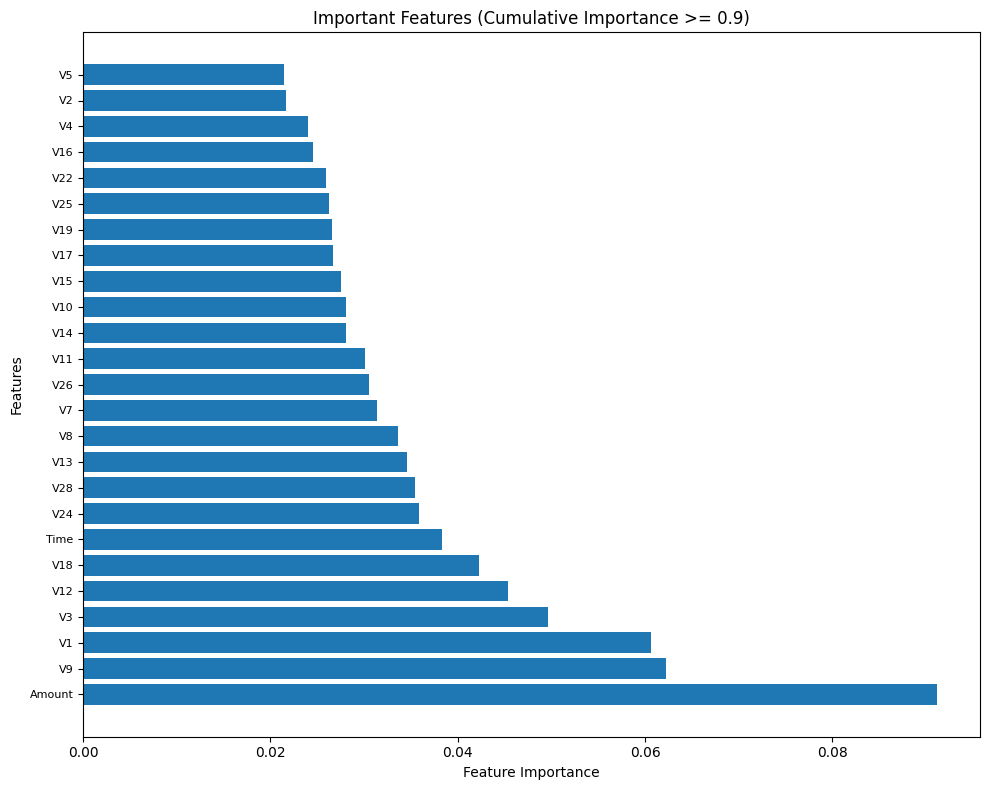

╒═══════════╤═══════════╕
│ Feature   │    Weight │
╞═══════════╪═══════════╡
│ Amount    │ 0.10112   │
├───────────┼───────────┤
│ V9        │ 0.0689655 │
├───────────┼───────────┤
│ V1        │ 0.0671915 │
├───────────┼───────────┤
│ V3        │ 0.054995  │
├───────────┼───────────┤
│ V12       │ 0.0503382 │
├───────────┼───────────┤
│ V18       │ 0.046901  │
├───────────┼───────────┤
│ Time      │ 0.0424659 │
├───────────┼───────────┤
│ V24       │ 0.0398049 │
├───────────┼───────────┤
│ V28       │ 0.0392505 │
├───────────┼───────────┤
│ V13       │ 0.0383635 │
├───────────┼───────────┤
│ V8        │ 0.0372547 │
├───────────┼───────────┤
│ V7        │ 0.0348154 │
├───────────┼───────────┤
│ V26       │ 0.0338175 │
├───────────┼───────────┤
│ V11       │ 0.033374  │
├───────────┼───────────┤
│ V14       │ 0.0311564 │
├───────────┼───────────┤
│ V10       │ 0.0311564 │
├───────────┼───────────┤
│ V15       │ 0.0304912 │
├───────────┼───────────┤
│ V17       │ 0.0296042 │
├───────────

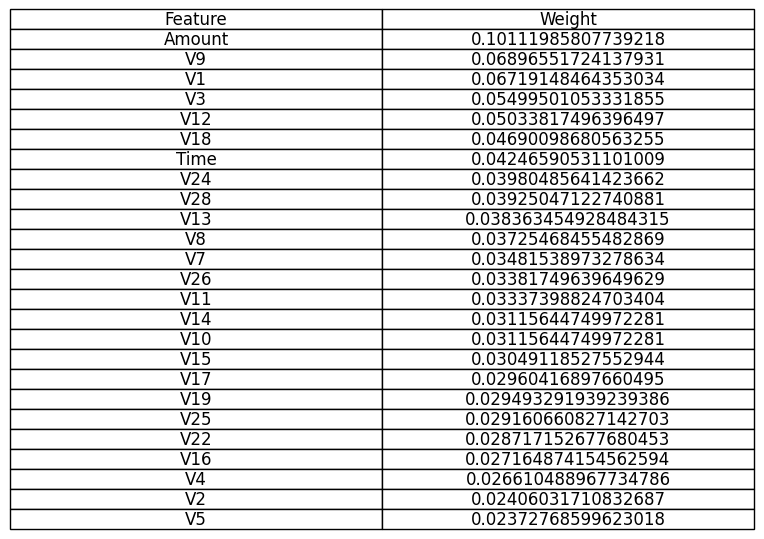

In [33]:
from tabulate import tabulate
# Step 10: Visualize the selected features
plt.figure(figsize=(10, 8))
plt.barh(range(len(important_features)), sorted_scores[:index+1], align='center')
plt.yticks(range(len(important_features)), important_features, fontsize=8)
plt.xlabel('Feature Importance', fontsize=10)
plt.ylabel('Features', fontsize=10)
plt.title('Important Features (Cumulative Importance >= 0.9)', fontsize=12)
plt.tight_layout()
plt.show()

# Step 11: Display the selected features and their weights in a table
important_scores = sorted_scores[:index+1]
total_importance = np.sum(important_scores)
weights = important_scores / total_importance

table_data = [[feature, weight] for feature, weight in zip(important_features, weights)]
headers = ["Feature", "Weight"]

# Print the table
table_str = tabulate(table_data, headers, tablefmt="fancy_grid")
print(table_str)

# Save the table as a PDF
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")
table = ax.table(cellText=table_data, colLabels=headers, cellLoc="center", loc="center")
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2)
plt.savefig("feature_importance_table.pdf", bbox_inches="tight")

# GridSearch application

In [34]:
from sklearn.model_selection import GridSearchCV
# Define Parameter Grids for GridSearchCV
param_grid_dt = {'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10]}
param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_et = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
param_grid_xgb = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.1, 0.2]}
param_grid_ada = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 1]}

In [35]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')
# Train and Tune Models
def grid_search(model, param_grid, name):
    grid = GridSearchCV(model, param_grid, cv=5, scoring=['accuracy', 'f1', 'roc_auc'], refit='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    print(f"Best parameters for {name}: {grid.best_params_}")
    return grid.best_estimator_


best_dt = grid_search(DecisionTreeClassifier(criterion='entropy', random_state=42), param_grid_dt, "Decision Tree")
best_rf = grid_search(RandomForestClassifier(random_state=42), param_grid_rf, "Random Forest")
best_et = grid_search(ExtraTreesClassifier(random_state=42), param_grid_et, "Extra Trees")
best_xgb = grid_search(XGBClassifier(n_estimators=50, eval_metric='logloss'), param_grid_xgb, "XGBoost")
best_ada = grid_search(AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=50), param_grid_ada, "AdaBoost")

Best parameters for Decision Tree: {'max_depth': None, 'min_samples_split': 2}
Best parameters for Random Forest: {'max_depth': None, 'n_estimators': 200}
Best parameters for Extra Trees: {'max_depth': None, 'n_estimators': 100}
Best parameters for XGBoost: {'learning_rate': 0.2, 'n_estimators': 200}
Best parameters for AdaBoost: {'learning_rate': 1, 'n_estimators': 200}


# Voting for best results

In [36]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical

# Step 1: Store Predictions for Meta-Model
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
meta_features_train = np.zeros((X_train.shape[0], 5))  # 5 models
meta_features_test = np.zeros((X_test.shape[0], 5))

# Base models
base_models = [
    ('dt', best_dt),
    ('rf', best_rf),
    ('et', best_et),
    ('xgb', best_xgb),
    ('ada', best_ada)
]
y_train = y_train.to_numpy()  # Convert to NumPy array

for train_idx, val_idx in skf.split(X_train, y_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    #y_tr, y_val = y_train[train_idx], y_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]


    
    # Train base models and store predictions for meta-model
    for i, (name, model) in enumerate(base_models):
        model.fit(X_tr, y_tr)
        meta_features_train[val_idx, i] = model.predict_proba(X_val)[:, 1]  # Use probabilities

# Fit final models on full training data to predict test meta-features
for i, (name, model) in enumerate(base_models):
    model.fit(X_train, y_train)
    meta_features_test[:, i] = model.predict_proba(X_test)[:, 1]

# Step 2: Define and Tune Voting Classifier with GridSearchCV
voting_clf = VotingClassifier(estimators=base_models, voting='soft')

# Tune Voting Weights Using GridSearchCV
param_grid_voting = {
    'weights': [
        (1, 1, 1, 1, 1),
        (1, 2, 2, 3, 1),
        (2, 1, 1, 1, 2),
        (3, 2, 1, 2, 1),
        (1, 1, 2, 2, 3)
    ]
}

grid_voting = GridSearchCV(voting_clf, param_grid_voting, cv=5, scoring='accuracy', n_jobs=-1)
grid_voting.fit(meta_features_train, y_train)  # Use meta-features for fitting

# Best Voting Classifier with Optimized Weights
best_voting = grid_voting.best_estimator_
print(f"Best Voting Weights: {grid_voting.best_params_}")


Best Voting Weights: {'weights': (1, 1, 1, 1, 1)}


# Second Stage : LSTM predictions

In [37]:
from tensorflow.keras.optimizers import Adam
# Step 3: LSTM Meta-Learner on top of Voting Classifier Predictions
best_voting.fit(X_train, y_train)

# Get Predictions from Voting Classifier (probabilities)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities of class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities of class 1

# Reshape for LSTM (required shape: [samples, time_steps, features])
X_train_lstm = y_pred_voting_train.reshape(-1, 1, 1)  # Shape (samples, 1, 1)
X_test_lstm = y_pred_voting_test.reshape(-1, 1, 1)  # Shape (samples, 1, 1)

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Check the shape of the labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)

Shape of y_train_cat: (284062, 2)
Shape of y_test_cat: (71016, 2)


# Final performance results

## Add autoencoders

In [38]:
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

# Define the Autoencoder
input_shape = (X_train_lstm.shape[1],)  # Adjust input shape based on your data
input_layer = Input(shape=input_shape)

# Encoder
encoded = Dense(256, activation='relu')(input_layer)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(128, activation='relu')(encoded)
encoded = BatchNormalization()(encoded)
encoded = Dropout(0.3)(encoded)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = BatchNormalization()(decoded)
decoded = Dropout(0.3)(decoded)
decoded = Dense(input_shape[0], activation='sigmoid')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Train the Autoencoder
autoencoder.fit(X_train_lstm, X_train_lstm,
                epochs=50,
                batch_size=32,
                validation_data=(X_test_lstm, X_test_lstm))

# Print model summary
autoencoder.summary()

# Step 3: Create an Encoder Model for Feature Extraction
encoder = Model(input_layer, encoded)

# Step 4: LSTM Meta-Learner on top of the encoded features
# (Assuming best_voting is a previously trained ensemble model)
y_pred_voting_train = best_voting.predict_proba(X_train)[:, 1]  # Probabilities for class 1
y_pred_voting_test = best_voting.predict_proba(X_test)[:, 1]  # Probabilities for class 1

# Convert Labels to Categorical
y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)

# Get the encoded representations (compressed features) for both train and test data
X_train_encoded = encoder.predict(X_train_lstm)
X_test_encoded = encoder.predict(X_test_lstm)

# Check the shape of the categorical labels
print("Shape of y_train_cat:", y_train_cat.shape)
print("Shape of y_test_cat:", y_test_cat.shape)


Epoch 1/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 9s 874us/step - loss: 0.0025 - val_loss: 5.5640e-04
Epoch 2/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 860us/step - loss: 0.0014 - val_loss: 5.9614e-04
Epoch 3/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 861us/step - loss: 0.0011 - val_loss: 4.1657e-04
Epoch 4/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 9.6779e-04 - val_loss: 4.4243e-04
Epoch 5/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 893us/step - loss: 9.3115e-04 - val_loss: 5.1066e-04
Epoch 6/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 866us/step - loss: 8.8159e-04 - val_loss: 4.1714e-04
Epoch 7/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 874us/step - loss: 8.3847e-04 - val_loss: 5.8643e-04
Epoch 8/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 873us/step - loss: 8.0514e-04 - val_loss: 4.5178e-04
Epoch 9/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 8.7851e-04 - val_loss: 5.4686e-04
Epoch 10/50
8877/8877 ━━━━━━━━━━━━━━━━━━━━ 8s 881us/step - loss: 8.2278e-04 - val_loss: 4.5214e-04
Epoch 11/50
8877/8877 ━━━━━━━━━━━━━

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 255,941 (999.77 KB)

 Trainable params: 84,801 (331.25 KB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 169,604 (662.52 KB)

8877/8877 ━━━━━━━━━━━━━━━━━━━━ 2s 199us/step
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 196us/step
Shape of y_train_cat: (284062, 2)
Shape of y_test_cat: (71016, 2)


In [39]:
X_train_encoded = X_train_encoded[:y_train_cat.shape[0]]
X_test_encoded = X_test_encoded[:y_test_cat.shape[0]]
#print("X_train_encoded shape:", X_train_encoded.shape)
#print("y_train_cat shape:", y_train_cat.shape)
#print("X_test_encoded shape:", X_test_encoded.shape)
# Ensure the shape is (samples, time_steps, features) for LSTM
X_train_lstm_ae = X_train_encoded.reshape(X_train_encoded.shape[0], 1, -1)
X_test_lstm_ae = X_test_encoded.reshape(X_test_encoded.shape[0], 1, -1)


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.metrics import Recall
from tensorflow.keras.regularizers import l2

# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # monitor validation loss
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs without improvement
    min_lr=1e-6            # do not go below this LR
)

# Define your LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.001)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.001)),
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])


# Define ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',    # monitor validation loss
    factor=0.5,            # reduce LR by half
    patience=3,            # wait 3 epochs without improvement
    min_lr=1e-6            # do not go below this LR
)

# LSTM Model
lstm_model = Sequential([
    #Input(shape=(X_train_lstm_ae.shape[1], X_train_lstm_ae.shape[2])),
    # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.3),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Now fit the LSTM Meta-Learner on the reshaped encoded data
history = lstm_model.fit(X_train_lstm_ae, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm_ae, y_test_cat), callbacks=[reduce_lr])

Epoch 1/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 11s 601us/step - accuracy: 0.9998 - loss: 0.0039 - recall: 0.9998 - val_accuracy: 0.9989 - val_loss: 0.0068 - val_recall: 0.9989 - learning_rate: 0.0010
Epoch 2/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 10s 580us/step - accuracy: 1.0000 - loss: 0.0015 - recall: 1.0000 - val_accuracy: 0.9994 - val_loss: 0.0116 - val_recall: 0.9994 - learning_rate: 0.0010
Epoch 3/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 10s 577us/step - accuracy: 0.9999 - loss: 0.0016 - recall: 0.9999 - val_accuracy: 0.9992 - val_loss: 0.0059 - val_recall: 0.9992 - learning_rate: 0.0010
Epoch 4/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 10s 587us/step - accuracy: 1.0000 - loss: 0.0011 - recall: 1.0000 - val_accuracy: 0.9991 - val_loss: 0.0075 - val_recall: 0.9991 - learning_rate: 0.0010
Epoch 5/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 10s 583us/step - accuracy: 0.9999 - loss: 0.0017 - recall: 0.9999 - val_accuracy: 0.9990 - val_loss: 0.0072 - val_recall: 0.9990 - learning_rate: 0.0010
Epoch 6/30
1671

In [41]:
# LSTM without Autoencoder Model
lstm_model_raw = Sequential([
    #Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
    
   # Première couche LSTM avec régularisation
    LSTM(64, return_sequences=False, kernel_regularizer=l2(0.001)),  
    BatchNormalization(),
    Dropout(0.4),  
    # Couche dense finale
    Dense(2, activation='softmax', kernel_regularizer=l2(0.001))
])

lstm_model_raw.compile(optimizer=AdamW(learning_rate=0.001, weight_decay=1e-4, beta_1=0.9, beta_2=0.999, epsilon=1e-7), loss='categorical_crossentropy', metrics=['accuracy', Recall()])

# Train the LSTM Meta-Learner
history_raw = lstm_model_raw.fit(X_train_lstm, y_train_cat, epochs=30, batch_size=17, validation_data=(X_test_lstm, y_test_cat), callbacks=[reduce_lr])#, callbacks=[early_stop], verbose=1)


Epoch 1/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 11s 578us/step - accuracy: 0.9999 - loss: 0.0033 - recall_1: 0.9999 - val_accuracy: 0.9990 - val_loss: 0.0048 - val_recall_1: 0.9990 - learning_rate: 0.0010
Epoch 2/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 10s 605us/step - accuracy: 0.9999 - loss: 0.0011 - recall_1: 0.9999 - val_accuracy: 0.9986 - val_loss: 0.0061 - val_recall_1: 0.9986 - learning_rate: 0.0010
Epoch 3/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 9s 544us/step - accuracy: 0.9999 - loss: 8.4592e-04 - recall_1: 0.9999 - val_accuracy: 0.9983 - val_loss: 0.0088 - val_recall_1: 0.9983 - learning_rate: 0.0010
Epoch 4/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 9s 546us/step - accuracy: 1.0000 - loss: 6.8837e-04 - recall_1: 1.0000 - val_accuracy: 0.9991 - val_loss: 0.0049 - val_recall_1: 0.9991 - learning_rate: 5.0000e-04
Epoch 5/30
16710/16710 ━━━━━━━━━━━━━━━━━━━━ 9s 548us/step - accuracy: 1.0000 - loss: 6.2303e-04 - recall_1: 1.0000 - val_accuracy: 0.9992 - val_loss: 0.0049 - val_recall_1: 0.9992 - lear

In [44]:
# Step 5: Evaluate LSTM Meta-Learner
y_pred_lstm_ae = lstm_model.predict(X_test_lstm_ae)
y_pred_lstm_ae_labels = np.argmax(y_pred_lstm_ae, axis=1)

y_pred_lstm_raw = lstm_model_raw.predict(X_test_lstm)
y_pred_lstm_raw = np.argmax(y_pred_lstm_raw, axis=1)

accuracy_raw = accuracy_score(y_test, y_pred_lstm_raw)

# Calculate accuracy of LSTM Meta-Learner
final_accuracy = accuracy_score(y_test, y_pred_lstm_ae_labels)
#print("Final LSTM Meta-Learner Accuracy:", final_accuracy)

2220/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 217us/step
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 0s 212us/step


In [45]:
print("Accuracy without Autoencoder:", accuracy_raw)
print("Accuracy with Autoencoder:", final_accuracy)

Accuracy without Autoencoder: 0.9989157372986369
Accuracy with Autoencoder: 0.9990424693026924


Performance without Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39453
           1       1.00      1.00      1.00     31563

    accuracy                           1.00     71016
   macro avg       1.00      1.00      1.00     71016
weighted avg       1.00      1.00      1.00     71016

Confusion matrix:
[[39386    67]
 [   10 31553]]
Accuracy: 0.9989157372986369
Precision : 0.9978810879190386
Recall : 0.999683173335868
F1-Score : 0.998781317759524
F2-Score : 0.9993222357352792
Cohen's Kappa Score : 0.9978047690763865
Matthews Correlation Coefficient (MCC) : 0.9978060865597035
Specificity : 0.9983017767977087
G-means : 0.9989922362941409


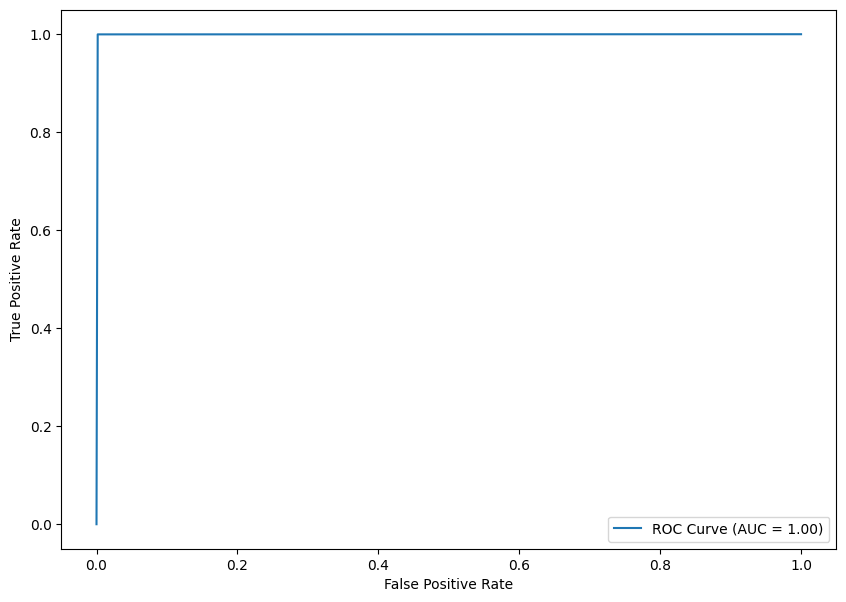

In [50]:
print("Performance without Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_raw))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lstm_raw))

print("Accuracy:", accuracy_score(y_test, y_pred_lstm_raw))
print("Precision :", precision_score(y_test, y_pred_lstm_raw))
print("Recall :", recall_score(y_test, y_pred_lstm_raw))
print("F1-Score :", f1_score(y_test, y_pred_lstm_raw))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_raw, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_raw))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_raw))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_raw).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_raw)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_raw)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Performance with Autoencoder :
Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39453
           1       1.00      1.00      1.00     31563

    accuracy                           1.00     71016
   macro avg       1.00      1.00      1.00     71016
weighted avg       1.00      1.00      1.00     71016

Confusion matrix:
[[39395    58]
 [   10 31553]]
Accuracy: 0.9990424693026924
Precision : 0.9981651956597387
Recall : 0.999683173335868
F1-Score : 0.9989236078133409
F2-Score : 0.9993792085542528
Cohen's Kappa Score : 0.9980612992423117
Matthews Correlation Coefficient (MCC) : 0.9980622338170535
Specificity : 0.9985298963323448
G-means : 0.9991063684294349


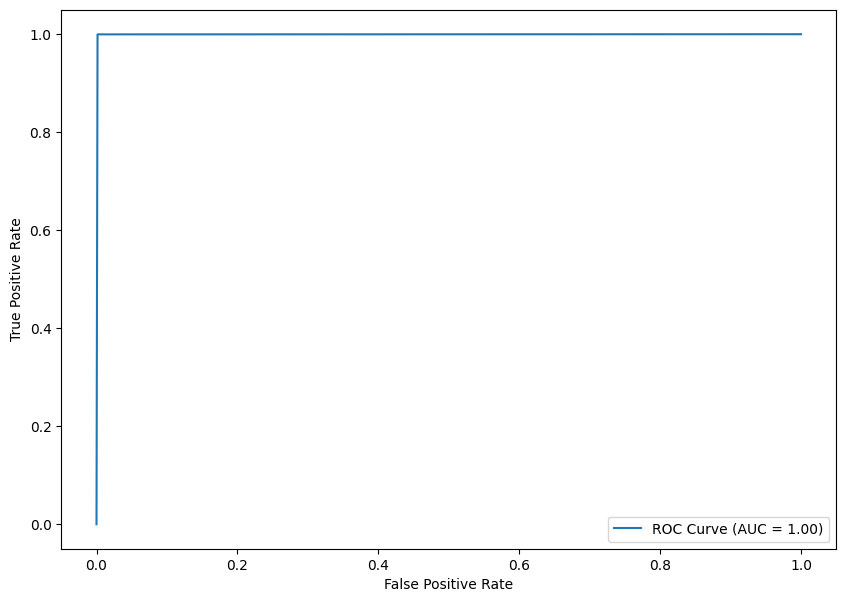

In [51]:
print("Performance with Autoencoder :")

print("Classification report:")
print(classification_report(y_test, y_pred_lstm_ae_labels))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_lstm_ae_labels))
print("Accuracy:", accuracy_score(y_test, y_pred_lstm_ae_labels))
print("Precision :", precision_score(y_test, y_pred_lstm_ae_labels))
print("Recall :", recall_score(y_test, y_pred_lstm_ae_labels))
print("F1-Score :", f1_score(y_test, y_pred_lstm_ae_labels))

# Compute F2-Score
f2 = fbeta_score(y_test, y_pred_lstm_ae_labels, beta=2)
print("F2-Score :", f2)
print("Cohen's Kappa Score :", cohen_kappa_score(y_test, y_pred_lstm_ae_labels))
print("Matthews Correlation Coefficient (MCC) :", matthews_corrcoef(y_test, y_pred_lstm_ae_labels))
# Calcul de la matrice de confusion
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_lstm_ae_labels).ravel()

# Calcul de la sensibilité (rappel)
sensitivity = tp / (tp + fn)

# Calcul de la spécificité
specificity = tn / (tn + fp)
print(f"Specificity : {specificity}")
# Calcul du G-means
g_means = np.sqrt(sensitivity * specificity)
print(f"G-means : {g_means}")
# Calculer l'AUC
#y_proba_trans = y_pred[:, 1]  # Extract probability of class 1
auc_score = roc_auc_score(y_test, y_pred_lstm_ae_labels)

# Calculer les valeurs FPR et TPR pour la courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_lstm_ae_labels)

# ROC Curve Data
plt.figure(figsize=(10, 7))

# Tracer la courbe ROC
plt.plot(fpr, tpr, label="ROC Curve (AUC = {:.2f})".format(auc_score))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [52]:
import pickle
from tensorflow.keras.models import load_model

# Sauvegarde du modèle avec pickle
with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(lstm_model, f)

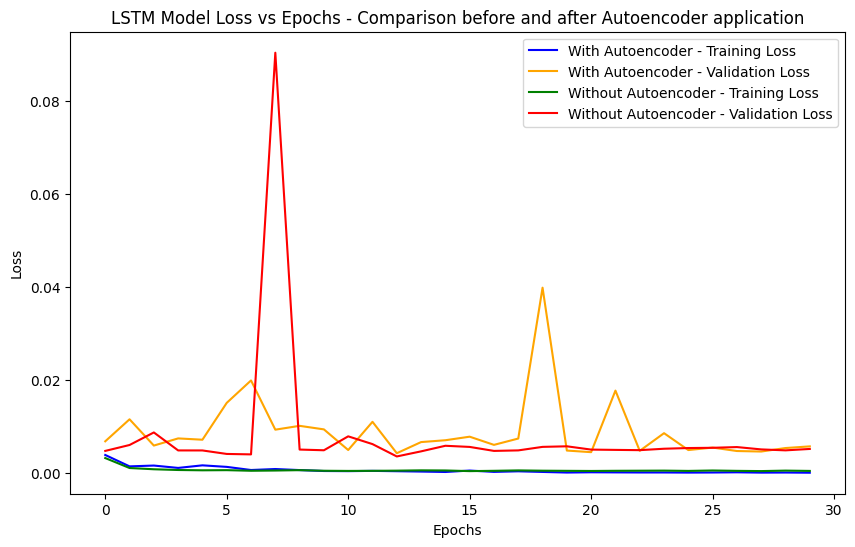

In [53]:
# Extract loss values
train_loss = history.history['loss']  # Training loss for each epoch
val_loss = history.history['val_loss']  # Validation loss for each epoch (if validation data is provided)

train_loss2 = history_raw.history['loss']
val_loss2 = history_raw.history['val_loss']

# Plotting the loss curves for both models
plt.figure(figsize=(10, 6))

# Plot for Model 1
plt.plot(train_loss, label='With Autoencoder - Training Loss', color='blue')
plt.plot(val_loss, label='With Autoencoder - Validation Loss', color='orange')

# Plot for Model 2
plt.plot(train_loss2, label='Without Autoencoder - Training Loss', color='green')
plt.plot(val_loss2, label='Without Autoencoder - Validation Loss', color='red')

# Adding labels and title
plt.title('LSTM Model Loss vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plot
plt.show()

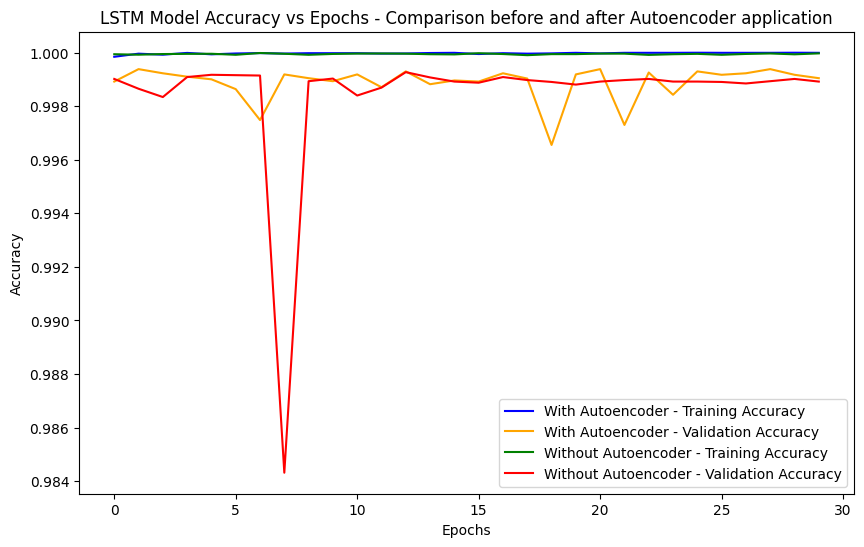

In [54]:
train_acc1 = history.history['accuracy']
val_acc1 = history.history['val_accuracy']

train_acc2 = history_raw.history['accuracy']
val_acc2 = history_raw.history['val_accuracy']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_acc1, label='With Autoencoder - Training Accuracy', color='blue')
plt.plot(val_acc1, label='With Autoencoder - Validation Accuracy', color='orange')

plt.plot(train_acc2, label='Without Autoencoder - Training Accuracy', color='green')
plt.plot(val_acc2, label='Without Autoencoder - Validation Accuracy', color='red')


plt.title('LSTM Model Accuracy vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

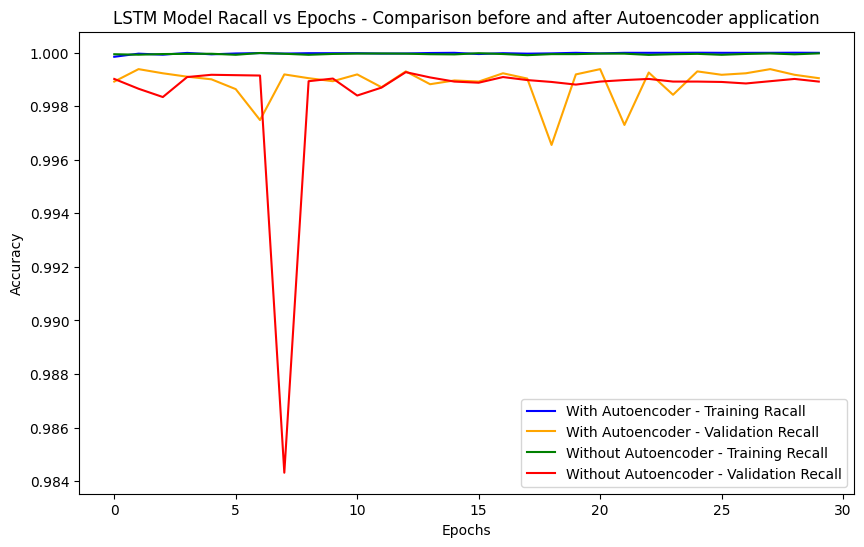

In [55]:
train_recall1 = history.history['recall']
val_recall1 = history.history['val_recall']

train_recall2 = history_raw.history['recall_1']
val_recall2 = history_raw.history['val_recall_1']

# Plotting accuracy for all models
plt.figure(figsize=(10, 6))
plt.plot(train_recall1, label='With Autoencoder - Training Racall', color='blue')
plt.plot(val_recall1, label='With Autoencoder - Validation Recall', color='orange')

plt.plot(train_recall2, label='Without Autoencoder - Training Recall', color='green')
plt.plot(val_recall2, label='Without Autoencoder - Validation Recall', color='red')


plt.title('LSTM Model Racall vs Epochs - Comparison before and after Autoencoder application')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

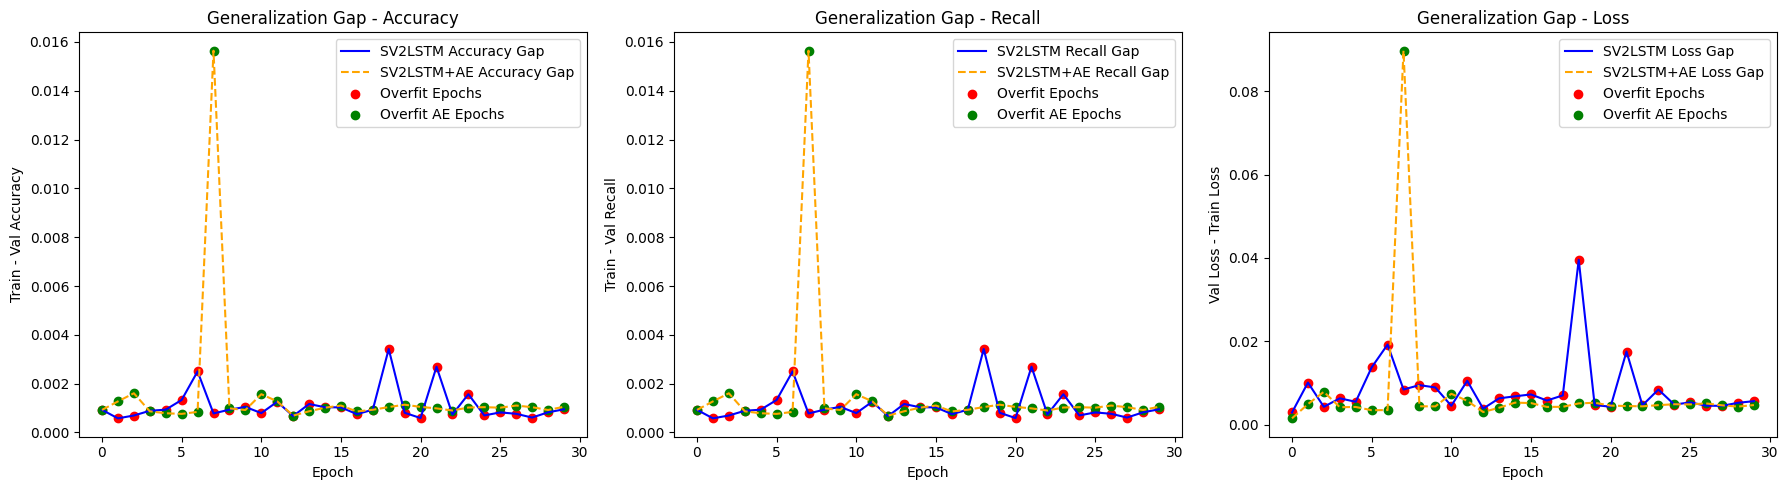

First overfitting epoch (Loss, SV2LSTM): 1
First overfitting epoch (Loss, SV2LSTM+AE): 1
First overfitting epoch (Accuracy, SV2LSTM): 1
First overfitting epoch (Accuracy, SV2LSTM+AE): 1
First overfitting epoch (Recall, SV2LSTM): 1
First overfitting epoch (Recall, SV2LSTM+AE): 1


In [56]:
import numpy as np
import matplotlib.pyplot as plt

# Accuracy and Recall over epochs
train_acc = history.history['accuracy']          # training accuracy per epoch
val_acc   = history.history['val_accuracy']      # validation accuracy per epoch

train_acc_raw = history_raw.history['accuracy']          # training accuracy per epoch
val_acc_raw   = history_raw.history['val_accuracy']      # validation accuracy per epoch


train_recall = history.history['recall']
val_recall = history.history['val_recall']

train_recall_raw = history_raw.history['recall_1']
val_recall_raw = history_raw.history['val_recall_1']


# Convert to numpy arrays
train_acc = np.array(train_acc)
val_acc   = np.array(val_acc)
train_acc_raw = np.array(train_acc_raw)
val_acc_raw   = np.array(val_acc_raw)

train_recall = np.array(train_recall)
val_recall   = np.array(val_recall)
train_recall_raw = np.array(train_recall_raw)
val_recall_raw   = np.array(val_recall_raw)

train_loss = np.array(history.history['loss'])
val_loss   = np.array(history.history['val_loss'])
train_loss2 = np.array(history_raw.history['loss'])
val_loss2   = np.array(history_raw.history['val_loss'])

# Compute generalization gaps
acc_gap = train_acc - val_acc
acc_gap_raw = train_acc_raw - val_acc_raw

recall_gap = train_recall - val_recall
recall_gap_raw = train_recall_raw - val_recall_raw

loss_gap = val_loss - train_loss
loss_gap_raw = val_loss2 - train_loss2

# Identify overfitting epochs
overfit_loss_epochs = np.where(loss_gap > 0)[0]
overfit_loss_epochs_raw = np.where(loss_gap_raw > 0)[0]

overfit_acc_epochs = np.where(acc_gap > 0)[0]
overfit_acc_epochs_raw = np.where(acc_gap_raw > 0)[0]

overfit_recall_epochs = np.where(recall_gap > 0)[0]
overfit_recall_epochs_raw = np.where(recall_gap_raw > 0)[0]

# Plotting
plt.figure(figsize=(18,5))

# Accuracy gap
plt.subplot(1,3,1)
plt.plot(acc_gap, label='SV2LSTM Accuracy Gap', color='blue', linestyle='-')
plt.plot(acc_gap_raw, label='SV2LSTM+AE Accuracy Gap', color='orange', linestyle='--')
plt.scatter(overfit_acc_epochs, acc_gap[overfit_acc_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_acc_epochs_raw, acc_gap_raw[overfit_acc_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Accuracy')
plt.grid(False)
plt.legend()

# Recall gap
plt.subplot(1,3,2)
plt.plot(recall_gap, label='SV2LSTM Recall Gap', color='blue', linestyle='-')
plt.plot(recall_gap_raw, label='SV2LSTM+AE Recall Gap', color='orange', linestyle='--')
plt.scatter(overfit_recall_epochs, recall_gap[overfit_recall_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_recall_epochs_raw, recall_gap_raw[overfit_recall_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Recall')
plt.xlabel('Epoch')
plt.ylabel('Train - Val Recall')
plt.grid(False)
plt.legend()

# Loss gap
plt.subplot(1,3,3)
plt.plot(loss_gap, label='SV2LSTM Loss Gap', color='blue')
plt.plot(loss_gap_raw, label='SV2LSTM+AE Loss Gap', color='orange', linestyle='--')
plt.scatter(overfit_loss_epochs, loss_gap[overfit_loss_epochs], color='red', label='Overfit Epochs')
plt.scatter(overfit_loss_epochs_raw, loss_gap_raw[overfit_loss_epochs_raw], color='green', label='Overfit AE Epochs')
plt.title('Generalization Gap - Loss')
plt.xlabel('Epoch')
plt.ylabel('Val Loss - Train Loss')
plt.grid(False)
plt.legend()

plt.tight_layout()
# Save the figure
plt.savefig("SV2LSTM_CCFD_SMOTE_generalization_gap.png", dpi=300)  # high-resolution PNG
plt.show()

# Optional: print first overfitting epoch for each metric
if len(overfit_loss_epochs) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM): {overfit_loss_epochs[0]+1}")
if len(overfit_loss_epochs_raw) > 0:
    print(f"First overfitting epoch (Loss, SV2LSTM+AE): {overfit_loss_epochs_raw[0]+1}")
if len(overfit_acc_epochs) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM): {overfit_acc_epochs[0]+1}")
if len(overfit_acc_epochs_raw) > 0:
    print(f"First overfitting epoch (Accuracy, SV2LSTM+AE): {overfit_acc_epochs_raw[0]+1}")
if len(overfit_recall_epochs) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM): {overfit_recall_epochs[0]+1}")
if len(overfit_recall_epochs_raw) > 0:
    print(f"First overfitting epoch (Recall, SV2LSTM+AE): {overfit_recall_epochs_raw[0]+1}")
